In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(r"C:\Users\Nicolas\LocalDocuments\HSLU\DSPRO2\runs")
ea.Reload()

# Get P1_stuck values — stuck=0 means finished
p1_stuck = ea.Scalars("episode/P1_stuck")
p2_stuck = ea.Scalars("episode/P2_stuck")

p1_finishes = sum(1 for s in p1_stuck if s.value == 0)
p2_finishes = sum(1 for s in p2_stuck if s.value == 0)

print(f"P1 finishes: {p1_finishes}")
print(f"P2 finishes: {p2_finishes}")
print(f"Total episodes with at least one finish: {sum(1 for p1, p2 in zip(p1_stuck, p2_stuck) if p1.value == 0 or p2.value == 0)}")

P1 finishes: 796
P2 finishes: 440
Total episodes with at least one finish: 1236


In [2]:
p1_rewards = ea.Scalars("episode/P1_reward")
best_p1 = max(p1_rewards, key=lambda s: s.value)
print(f"Best P1 episode: {best_p1.step} with reward {best_p1.value:.2f}")

Best P1 episode: 847 with reward 249.43


In [3]:
last_100 = [s.value for s in p1_rewards[-100:]]
print(f"P1 average reward last 100 episodes: {sum(last_100)/len(last_100):.2f}")

P1 average reward last 100 episodes: 137.86


In [4]:
action_totals = {}
for tag in ea.Tags()["scalars"]:
    if tag.startswith("actions/P1_"):
        name = tag.replace("actions/P1_", "")
        total = sum(s.value for s in ea.Scalars(tag))
        action_totals[name] = total

for action, count in sorted(action_totals.items(), key=lambda x: -x[1]):
    print(f"{action}: {int(count)}")

accel_right: 1721964
drift_hard_left: 626104
wheelie_left: 364870
drift_hard_right: 51090
drift_soft_right: 24524
drift_soft_left: 15419
wheelie_center: 7841
brake_right: 7070
brake_center: 6334
accel_left: 4841
accel_center: 3877
drift_center: 3587
nothing: 3340
brake_left: 3116
wheelie_right: 3070


In [5]:
import numpy as np
stuck_values = [s.value for s in p1_stuck]
window = 500
rolling = [1 - np.mean(stuck_values[i:i+window]) for i in range(len(stuck_values)-window)]
print(f"Finish rate first 500 episodes: {rolling[0]:.1%}")
print(f"Finish rate last 500 episodes: {rolling[-1]:.1%}")

Finish rate first 500 episodes: 0.0%
Finish rate last 500 episodes: 69.2%


In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from datetime import timedelta
import numpy as np

ea = EventAccumulator(r"C:\Users\Nicolas\LocalDocuments\HSLU\DSPRO2\runs")
ea.Reload()

scalars = ea.Scalars("train/loss")
p1_stuck = ea.Scalars("episode/P1_stuck")
p1_progress = ea.Scalars("episode/P1_progress")

# Training time
times = [s.wall_time for s in scalars]
gaps = np.diff(times)
BREAK_THRESHOLD = 300
compute_gaps = gaps[gaps < BREAK_THRESHOLD]
compute_time = timedelta(seconds=float(compute_gaps.sum()))
print(f"Estimated compute time: {compute_time}")

# Save state analysis
finished_episodes = [(s.step, p.value) for s, p in zip(p1_stuck, p1_progress) if s.value == 0]
early_start = [(ep, prog) for ep, prog in finished_episodes if prog > 2.5]
mid_start = [(ep, prog) for ep, prog in finished_episodes if 1.5 < prog <= 2.5]
late_start = [(ep, prog) for ep, prog in finished_episodes if prog <= 1.5]
print(f"Started near beginning (progress >2.5): {len(early_start)}")
print(f"Started mid-track (1.5-2.5): {len(mid_start)}")
print(f"Started late (progress <1.5): {len(late_start)}")

Estimated compute time: 1 day, 4:58:33.935816
Started near beginning (progress >2.5): 326
Started mid-track (1.5-2.5): 470
Started late (progress <1.5): 0


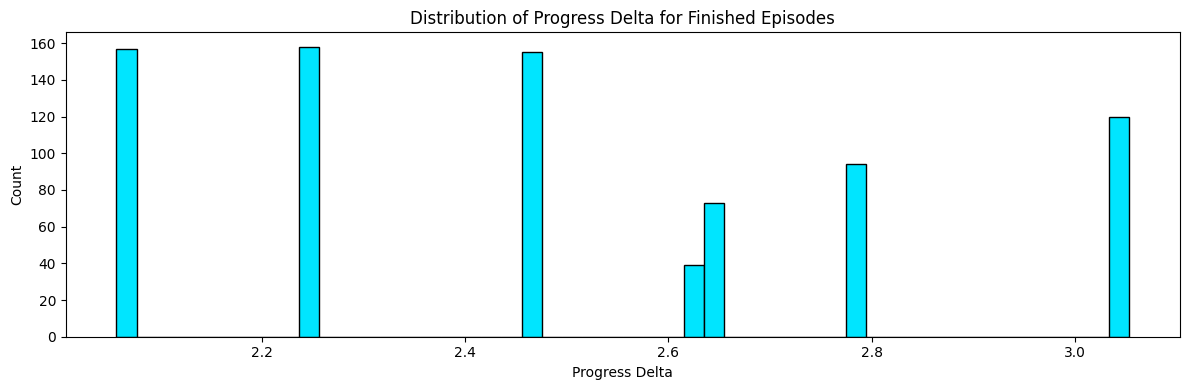

Progress ~2.1: 157 episodes
Progress ~2.3: 158 episodes
Progress ~2.5: 155 episodes
Progress ~2.6: 112 episodes
Progress ~2.8: 94 episodes
Progress ~3.1: 120 episodes


In [8]:
import matplotlib.pyplot as plt

finished_progress = [prog for _, prog in finished_episodes]

plt.figure(figsize=(12, 4))
plt.hist(finished_progress, bins=50, color='#00E5FF', edgecolor='black')
plt.xlabel('Progress Delta')
plt.ylabel('Count')
plt.title('Distribution of Progress Delta for Finished Episodes')
plt.tight_layout()
plt.show()

# Also print the distinct clusters
import numpy as np
rounded = [round(p, 1) for p in finished_progress]
from collections import Counter
for val, count in sorted(Counter(rounded).items()):
    print(f"Progress ~{val}: {count} episodes")

In [9]:
p1_rewards = ea.Scalars("episode/P1_reward")

# Match rewards to progress clusters for finished episodes
def get_cluster(progress):
    if progress < 2.2:
        return "~2.1 (latest start)"
    elif progress < 2.4:
        return "~2.3"
    elif progress < 2.55:
        return "~2.5"
    elif progress < 2.7:
        return "~2.6"
    elif progress < 2.9:
        return "~2.8"
    else:
        return "~3.1 (earliest start)"

# Build step->reward lookup
reward_by_step = {s.step: s.value for s in p1_rewards}

# Cross reference
from collections import defaultdict
cluster_rewards = defaultdict(list)

for step, prog in finished_episodes:
    if step in reward_by_step:
        cluster = get_cluster(prog)
        cluster_rewards[cluster].append(reward_by_step[step])

for cluster, rewards in sorted(cluster_rewards.items()):
    print(f"{cluster}: avg={sum(rewards)/len(rewards):.1f} min={min(rewards):.1f} max={max(rewards):.1f} n={len(rewards)}")
    

~2.1 (latest start): avg=130.6 min=101.3 max=194.1 n=157
~2.3: avg=139.0 min=118.1 max=163.2 n=158
~2.5: avg=146.9 min=129.9 max=181.7 n=155
~2.6: avg=154.8 min=145.9 max=208.4 n=112
~2.8: avg=162.3 min=150.1 max=249.4 n=94
~3.1 (earliest start): avg=170.0 min=157.0 max=217.0 n=120
